# IMDb Spoiler Detection using Natural Language Processing

Notebook ini membangun model klasifikasi spoiler review IMDb dengan seluruh dataset tanpa balancing. Alur dibuat mengikuti `NLPB.ipynb`: EDA visual, fitur `review_text` + `word_count`, TF-IDF dengan custom stop words, dan pipeline model. Model dibandingkan berdasarkan F1-Score, lalu model terbaik diuji pada 20 sample acak dan disimpan.

## Data & Libraries

In [1]:
# ================================
# Libraries & Setup
# ================================

import os
import json
import subprocess
import warnings
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from dotenv import load_dotenv
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer, ENGLISH_STOP_WORDS
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve,
    auc,
)
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB, ComplementNB
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC
from sklearn.linear_model import SGDClassifier, PassiveAggressiveClassifier

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

RANDOM_STATE = 42

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [2]:
# ================================
# Get Data
# ================================

env_path = Path(".env")
load_dotenv(env_path)

kaggle_username = os.getenv("KAGGLE_USERNAME")
kaggle_key = os.getenv("KAGGLE_KEY")

if kaggle_username:
    os.environ["KAGGLE_USERNAME"] = kaggle_username
if kaggle_key:
    os.environ["KAGGLE_KEY"] = kaggle_key

dataset_dir = Path("data/imdb_spoiler_dataset")
cache_dir = Path("data/cache")

dataset_dir.mkdir(parents=True, exist_ok=True)
cache_dir.mkdir(parents=True, exist_ok=True)

reviews_path = dataset_dir / "IMDB_reviews.json"
raw_cache_path = cache_dir / "df_raw.pkl"

if not reviews_path.exists():
    print("Dataset not found. Downloading from Kaggle...")
    subprocess.run(
        [
            "kaggle",
            "datasets",
            "download",
            "-d",
            "rmisra/imdb-spoiler-dataset",
            "-p",
            str(dataset_dir),
            "--unzip",
        ],
        check=True,
    )
    print("Download completed.")
else:
    print("Dataset already exists. Using local data.")

if raw_cache_path.exists():
    print("Loading full dataset from cache...")
    df = pd.read_pickle(raw_cache_path)
else:
    print("Loading full dataset from JSON...")
    df = pd.read_json(reviews_path, lines=True)
    df = df[["review_text", "is_spoiler"]]
    df["is_spoiler"] = df["is_spoiler"].astype(int)
    df.to_pickle(raw_cache_path)
    print("Full dataset saved to cache.")

# Pastikan format kolom konsisten jika cache lama dipakai.
df = df[["review_text", "is_spoiler"]].copy()
df["review_text"] = df["review_text"].fillna("").astype(str)
df["is_spoiler"] = df["is_spoiler"].astype(int)

print(f"Total rows: {df.shape[0]:,}")
df.head()

Dataset already exists. Using local data.
Loading full dataset from cache...
Total rows: 573,913


,review_text,is_spoiler
0,"In its Oscar year, Shawshank Redemption (writt...",1
1,The Shawshank Redemption is without a doubt on...,1
2,I believe that this film is the best story eve...,1
3,"**Yes, there are SPOILERS here**This film has ...",1
4,At the heart of this extraordinary movie is a ...,1


## Exploratory Data Analysis

In [3]:
print("Dataset shape:", df.shape)
print("\nMissing values:")
print(df.isnull().sum())

print("\nLabel distribution:")
print(df["is_spoiler"].value_counts())

print("\nLabel proportion:")
print(df["is_spoiler"].value_counts(normalize=True))

df.head()

Dataset shape: (573913, 2)

Missing values:
review_text    0
is_spoiler     0
dtype: int64

Label distribution:
is_spoiler
0    422989
1    150924
Name: count, dtype: int64

Label proportion:
is_spoiler
0    0.737026
1    0.262974
Name: proportion, dtype: float64


,review_text,is_spoiler
0,"In its Oscar year, Shawshank Redemption (writt...",1
1,The Shawshank Redemption is without a doubt on...,1
2,I believe that this film is the best story eve...,1
3,"**Yes, there are SPOILERS here**This film has ...",1
4,At the heart of this extraordinary movie is a ...,1


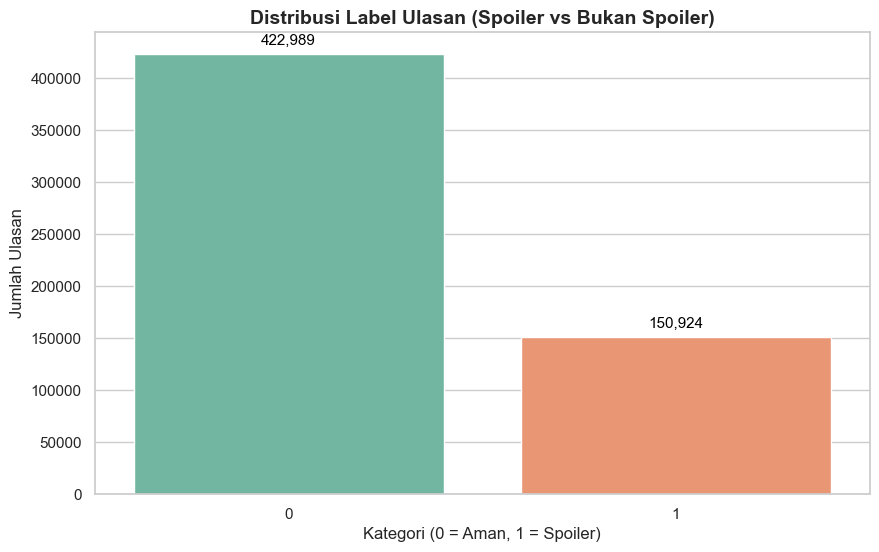

Rasio Data - Aman: 73.70% | Spoiler: 26.30%


In [4]:
ax = sns.countplot(data=df, x="is_spoiler", palette="Set2")
plt.title("Distribusi Label Ulasan (Spoiler vs Bukan Spoiler)", fontsize=14, fontweight="bold")
plt.xlabel("Kategori (0 = Aman, 1 = Spoiler)")
plt.ylabel("Jumlah Ulasan")

for p in ax.patches:
    ax.annotate(
        f"{int(p.get_height()):,}",
        (p.get_x() + p.get_width() / 2.0, p.get_height()),
        ha="center",
        va="bottom",
        fontsize=11,
        color="black",
        xytext=(0, 5),
        textcoords="offset points",
    )

plt.show()

imbalance = df["is_spoiler"].value_counts(normalize=True) * 100
print(f"Rasio Data - Aman: {imbalance.get(0, 0):.2f}% | Spoiler: {imbalance.get(1, 0):.2f}%")

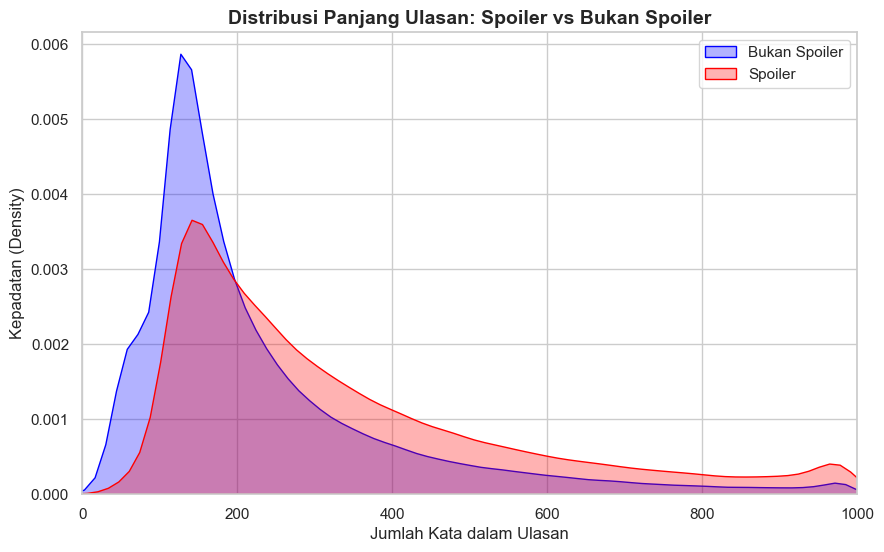

Rata-rata panjang kata ulasan AMAN    : 231.8
Rata-rata panjang kata ulasan SPOILER : 334.65


In [5]:
# Menghitung jumlah kata per ulasan sebagai fitur numerik tambahan.
df["word_count"] = df["review_text"].apply(lambda text: len(str(text).split()))

sns.kdeplot(
    data=df[df["is_spoiler"] == 0]["word_count"],
    label="Bukan Spoiler",
    fill=True,
    color="blue",
    alpha=0.3,
)
sns.kdeplot(
    data=df[df["is_spoiler"] == 1]["word_count"],
    label="Spoiler",
    fill=True,
    color="red",
    alpha=0.3,
)

plt.title("Distribusi Panjang Ulasan: Spoiler vs Bukan Spoiler", fontsize=14, fontweight="bold")
plt.xlabel("Jumlah Kata dalam Ulasan")
plt.ylabel("Kepadatan (Density)")
plt.xlim(0, 1000)
plt.legend()
plt.show()

print("Rata-rata panjang kata ulasan AMAN    :", round(df[df["is_spoiler"] == 0]["word_count"].mean(), 2))
print("Rata-rata panjang kata ulasan SPOILER :", round(df[df["is_spoiler"] == 1]["word_count"].mean(), 2))

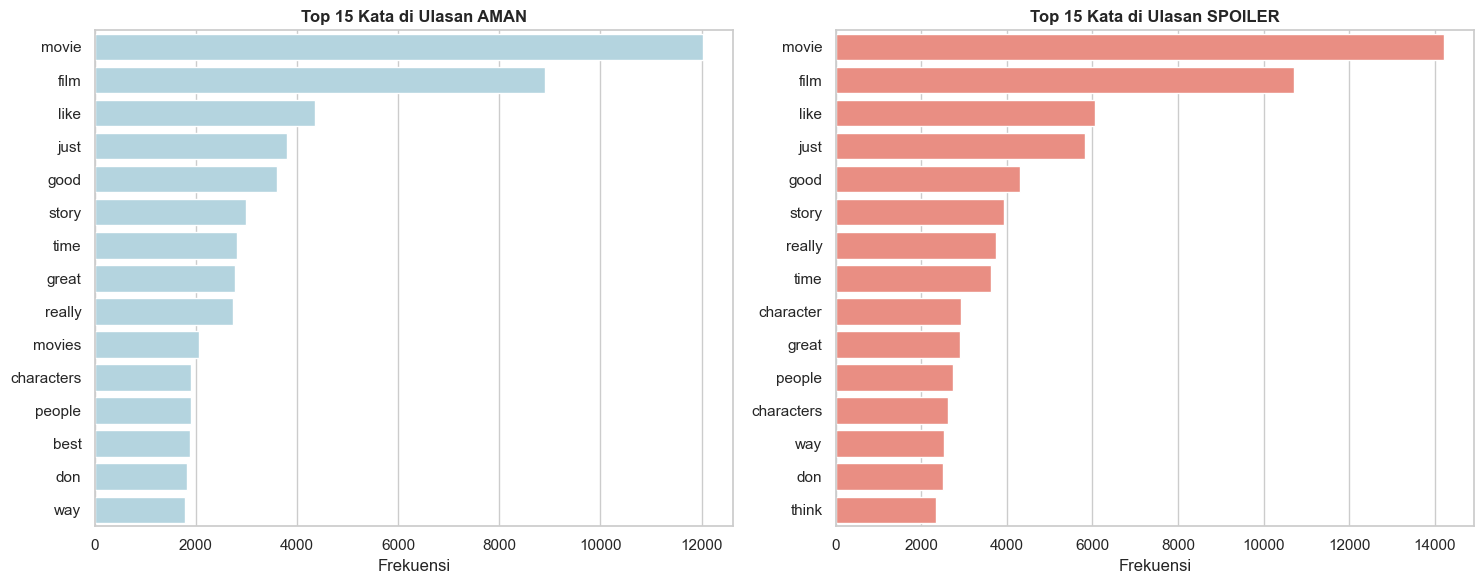

In [6]:
def plot_top_words(corpus, title, color):
    vec = CountVectorizer(stop_words="english", max_features=15).fit(corpus)
    bag_of_words = vec.transform(corpus)
    sum_words = bag_of_words.sum(axis=0)

    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    words_freq = sorted(words_freq, key=lambda item: item[1], reverse=True)

    words, freqs = zip(*words_freq)

    sns.barplot(x=list(freqs), y=list(words), color=color)
    plt.title(title, fontsize=12, fontweight="bold")
    plt.xlabel("Frekuensi")

sample_size = min(5000, df["is_spoiler"].value_counts().min())
sample_spoiler = df[df["is_spoiler"] == 1]["review_text"].sample(sample_size, random_state=RANDOM_STATE)
sample_safe = df[df["is_spoiler"] == 0]["review_text"].sample(sample_size, random_state=RANDOM_STATE)

plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
plot_top_words(sample_safe, "Top 15 Kata di Ulasan AMAN", "lightblue")

plt.subplot(1, 2, 2)
plot_top_words(sample_spoiler, "Top 15 Kata di Ulasan SPOILER", "salmon")

plt.tight_layout()
plt.show()

Dataset digunakan seluruhnya tanpa balancing. Ketidakseimbangan label tetap dipertahankan agar eksperimen merepresentasikan distribusi asli data.

## Preprocessing & Feature Engineering

In [7]:
# ================================
# Preprocessing mengikuti NLPB.ipynb
# ================================

# Tidak memakai cleaning NLTK panjang. Teks mentah tetap dipakai agar konteks review tidak hilang.
# Preprocessing dilakukan di dalam pipeline lewat TF-IDF + custom stop words, ditambah fitur word_count.

df["review_text"] = df["review_text"].fillna("").astype(str)
df["word_count"] = df["review_text"].apply(lambda text: len(str(text).split()))

custom_stop_words = list(
    ENGLISH_STOP_WORDS.union(
        [
            "movie",
            "film",
            "movies",
            "like",
            "just",
            "good",
            "story",
            "time",
            "really",
            "character",
            "characters",
            "people",
        ]
    )
)

text_features = ["review_text"]
meta_features = ["word_count"]
feature_columns = text_features + meta_features

text_preprocessor = ColumnTransformer(
    transformers=[
        (
            "text_tfidf",
            TfidfVectorizer(
                stop_words=custom_stop_words,
                max_features=15000,
                ngram_range=(1, 2),
            ),
            "review_text",
        ),
    ]
)

full_preprocessor = ColumnTransformer(
    transformers=[
        (
            "text_tfidf",
            TfidfVectorizer(
                stop_words=custom_stop_words,
                max_features=15000,
                ngram_range=(1, 2),
            ),
            "review_text",
        ),
        ("num_scaler", StandardScaler(), meta_features),
    ]
)

print("Preprocessing setup completed.")
df[["review_text", "word_count", "is_spoiler"]].head()

Preprocessing setup completed.


,review_text,word_count,is_spoiler
0,"In its Oscar year, Shawshank Redemption (writt...",843,1
1,The Shawshank Redemption is without a doubt on...,223,1
2,I believe that this film is the best story eve...,250,1
3,"**Yes, there are SPOILERS here**This film has ...",741,1
4,At the heart of this extraordinary movie is a ...,829,1


## Data Splitting

In [8]:
X = df[feature_columns]
y = df["is_spoiler"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y,
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Train label proportion:")
print(y_train.value_counts(normalize=True))
print("\nTest label proportion:")
print(y_test.value_counts(normalize=True))

Train shape: (459130, 2)
Test shape: (114783, 2)
Train label proportion:
is_spoiler
0    0.737027
1    0.262973
Name: proportion, dtype: float64

Test label proportion:
is_spoiler
0    0.737026
1    0.262974
Name: proportion, dtype: float64


## Feature Extraction

In [9]:
# ================================
# Feature Extraction
# ================================

print("Feature extraction masuk ke dalam Pipeline:")
print("- TF-IDF unigram + bigram dari review_text")
print("- max_features = 15000")
print("- custom English stop words dari NLPB.ipynb")
print("- word_count sebagai fitur numerik tambahan")

# Preview bentuk fitur untuk memastikan transformer berjalan.
feature_preview = clone(full_preprocessor).fit_transform(X_train.head(1000))
print("Preview feature shape:", feature_preview.shape)

Feature extraction masuk ke dalam Pipeline:
- TF-IDF unigram + bigram dari review_text
- max_features = 15000
- custom English stop words dari NLPB.ipynb
- word_count sebagai fitur numerik tambahan
Preview feature shape: (1000, 15001)


## Modelling

In [10]:
# ================================
# Model Training
# ================================

models = {
    "SGD Classifier + Meta Feature (NLPB)": Pipeline(
        steps=[
            ("preprocessor", full_preprocessor),
            (
                "classifier",
                SGDClassifier(
                    loss="modified_huber",
                    penalty="l2",
                    alpha=1e-4,
                    class_weight="balanced",
                    max_iter=1000,
                    random_state=RANDOM_STATE,
                ),
            ),
        ]
    ),
    "Linear SVC + Meta Feature": Pipeline(
        steps=[
            ("preprocessor", full_preprocessor),
            (
                "classifier",
                LinearSVC(
                    C=0.1,
                    class_weight="balanced",
                    max_iter=3000,
                    random_state=RANDOM_STATE,
                ),
            ),
        ]
    ),
    "Passive Aggressive + Meta Feature": Pipeline(
        steps=[
            ("preprocessor", full_preprocessor),
            (
                "classifier",
                PassiveAggressiveClassifier(
                    C=0.5,
                    class_weight="balanced",
                    max_iter=1000,
                    random_state=RANDOM_STATE,
                ),
            ),
        ]
    ),
    "Multinomial Naive Bayes": Pipeline(
        steps=[
            ("preprocessor", text_preprocessor),
            ("classifier", MultinomialNB()),
        ]
    ),
    "Complement Naive Bayes": Pipeline(
        steps=[
            ("preprocessor", text_preprocessor),
            ("classifier", ComplementNB()),
        ]
    ),
}

results = []
model_objects = {}
model_predictions = {}

print("Mulai melatih model Machine Learning...")

for name, model in models.items():
    print(f"--> Sedang melatih {name}...")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    model_objects[name] = model
    model_predictions[name] = y_pred

    results.append(
        {
            "Model": name,
            "Accuracy": accuracy_score(y_test, y_pred),
            "Precision": precision_score(y_test, y_pred, zero_division=0),
            "Recall": recall_score(y_test, y_pred, zero_division=0),
            "F1-Score": f1_score(y_test, y_pred, zero_division=0),
        }
    )

print("Pelatihan selesai!\n")

results_df = pd.DataFrame(results).sort_values(by="F1-Score", ascending=False).reset_index(drop=True)
results_df

Mulai melatih model Machine Learning...
--> Sedang melatih SGD Classifier + Meta Feature (NLPB)...
--> Sedang melatih Linear SVC + Meta Feature...
--> Sedang melatih Passive Aggressive + Meta Feature...
--> Sedang melatih Multinomial Naive Bayes...
--> Sedang melatih Complement Naive Bayes...
Pelatihan selesai!



,Model,Accuracy,Precision,Recall,F1-Score
0,SGD Classifier + Meta Feature (NLPB),0.718521,0.475049,0.669869,0.555884
1,Linear SVC + Meta Feature,0.720429,0.477246,0.661852,0.554590
2,Passive Aggressive + Meta Feature,0.680449,0.431272,0.675004,0.526289
3,Complement Naive Bayes,0.680092,0.429040,0.654497,0.518313
4,Multinomial Naive Bayes,0.757403,0.690317,0.140533,0.233526


## Model Evaluation

In [11]:
# ================================
# Select Best Model by F1-Score
# ================================

best_result = results_df.sort_values(by="F1-Score", ascending=False).iloc[0]

best_model_name = best_result["Model"]
best_model = model_objects[best_model_name]
best_pred = model_predictions[best_model_name]

print("Best Model:", best_model_name)
print(f"Best F1-Score: {best_result['F1-Score']:.4f}")
print(f"Precision: {best_result['Precision']:.4f}")
print(f"Recall: {best_result['Recall']:.4f}")
print(f"Accuracy: {best_result['Accuracy']:.4f}")

Best Model: SGD Classifier + Meta Feature (NLPB)
Best F1-Score: 0.5559
Precision: 0.4750
Recall: 0.6699
Accuracy: 0.7185


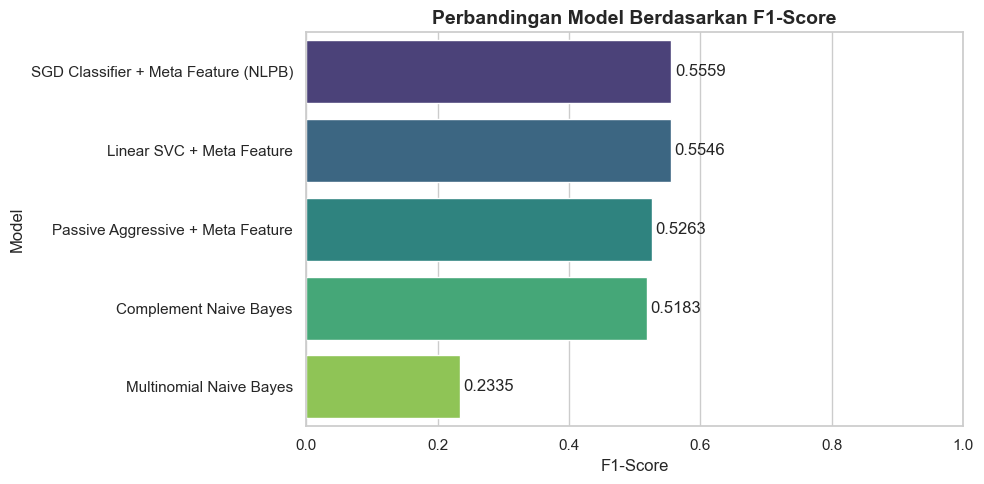

In [12]:
plt.figure(figsize=(10, 5))
sns.barplot(data=results_df, x="F1-Score", y="Model", palette="viridis")
plt.title("Perbandingan Model Berdasarkan F1-Score", fontsize=14, fontweight="bold")
plt.xlabel("F1-Score")
plt.ylabel("Model")
plt.xlim(0, 1)

for index, row in results_df.iterrows():
    plt.text(row["F1-Score"] + 0.005, index, f"{row['F1-Score']:.4f}", va="center")

plt.tight_layout()
plt.show()

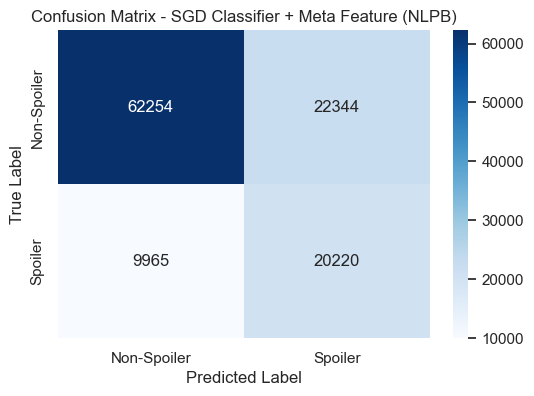

In [13]:
# ================================
# Confusion Matrix of Best Model
# ================================

cm = confusion_matrix(y_test, best_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Non-Spoiler", "Spoiler"],
    yticklabels=["Non-Spoiler", "Spoiler"],
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title(f"Confusion Matrix - {best_model_name}")
plt.show()

In [14]:
# ================================
# Classification Report of Best Model
# ================================

print(classification_report(
    y_test,
    best_pred,
    target_names=["Non-Spoiler", "Spoiler"],
    zero_division=0,
))

              precision    recall  f1-score   support

 Non-Spoiler       0.86      0.74      0.79     84598
     Spoiler       0.48      0.67      0.56     30185

    accuracy                           0.72    114783
   macro avg       0.67      0.70      0.67    114783
weighted avg       0.76      0.72      0.73    114783



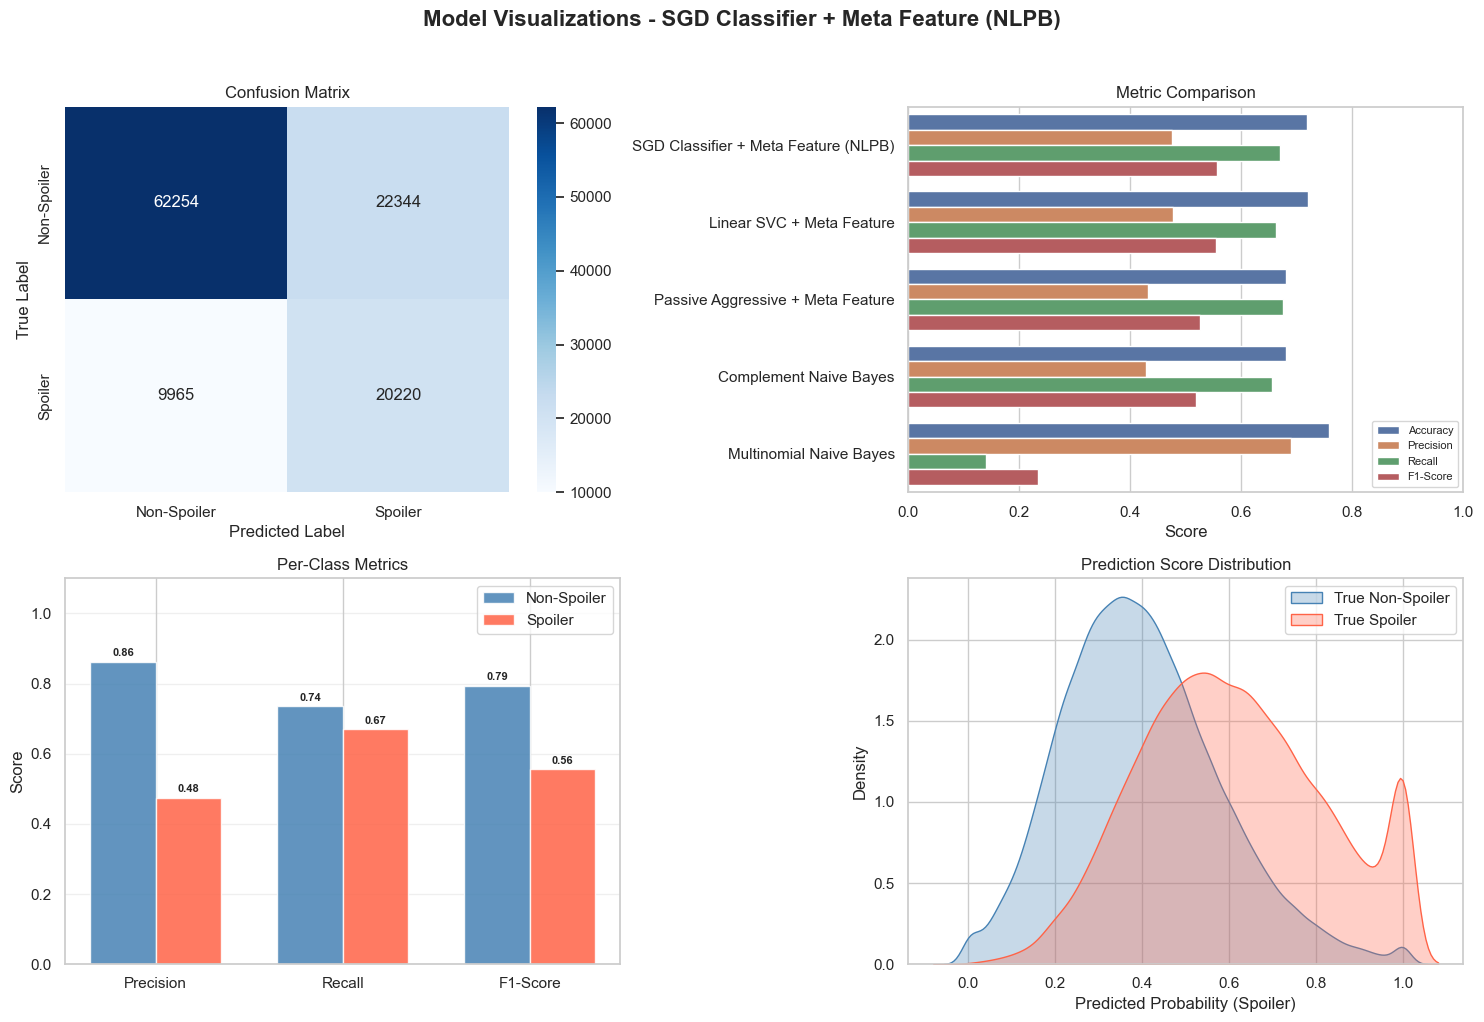

Visualizations saved to figures/best_model_visualization.png


In [15]:
# ================================
# Best Model Visualizations
# ================================

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle(f"Model Visualizations - {best_model_name}", fontsize=16, fontweight="bold", y=1.02)

# 1. Confusion Matrix
ax1 = axes[0, 0]
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Non-Spoiler", "Spoiler"],
    yticklabels=["Non-Spoiler", "Spoiler"],
    ax=ax1,
)
ax1.set_xlabel("Predicted Label")
ax1.set_ylabel("True Label")
ax1.set_title("Confusion Matrix")

# 2. Per-model metric comparison
ax2 = axes[0, 1]
metric_df = results_df.melt(
    id_vars="Model",
    value_vars=["Accuracy", "Precision", "Recall", "F1-Score"],
    var_name="Metric",
    value_name="Score",
)
sns.barplot(data=metric_df, x="Score", y="Model", hue="Metric", ax=ax2)
ax2.set_xlim(0, 1)
ax2.set_title("Metric Comparison")
ax2.set_xlabel("Score")
ax2.set_ylabel("")
ax2.legend(loc="lower right", fontsize=8)

# 3. Per-class metrics for best model
ax3 = axes[1, 0]
report = classification_report(
    y_test,
    best_pred,
    target_names=["Non-Spoiler", "Spoiler"],
    output_dict=True,
    zero_division=0,
)
classes = ["Non-Spoiler", "Spoiler"]
metrics_names = ["precision", "recall", "f1-score"]
x = np.arange(len(metrics_names))
width = 0.35
colors = ["steelblue", "tomato"]

for i, cls in enumerate(classes):
    values = [report[cls][metric] for metric in metrics_names]
    bars = ax3.bar(x + i * width, values, width, label=cls, color=colors[i], alpha=0.85)
    for bar, value in zip(bars, values):
        ax3.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.01,
            f"{value:.2f}",
            ha="center",
            va="bottom",
            fontsize=8,
            fontweight="bold",
        )

ax3.set_xticks(x + width / 2)
ax3.set_xticklabels(["Precision", "Recall", "F1-Score"])
ax3.set_ylim(0, 1.1)
ax3.set_ylabel("Score")
ax3.set_title("Per-Class Metrics")
ax3.legend()
ax3.grid(True, axis="y", alpha=0.3)

# 4. Probability or decision score distribution
ax4 = axes[1, 1]
if hasattr(best_model, "predict_proba"):
    best_scores = best_model.predict_proba(X_test)[:, 1]
    score_label = "Predicted Probability (Spoiler)"
elif hasattr(best_model, "decision_function"):
    best_scores = best_model.decision_function(X_test)
    score_label = "Decision Score (Spoiler)"
else:
    best_scores = None

if best_scores is not None:
    y_test_array = y_test.to_numpy()
    sns.kdeplot(x=best_scores[y_test_array == 0], label="True Non-Spoiler", fill=True, color="steelblue", alpha=0.3, ax=ax4)
    sns.kdeplot(x=best_scores[y_test_array == 1], label="True Spoiler", fill=True, color="tomato", alpha=0.3, ax=ax4)
    ax4.set_xlabel(score_label)
    ax4.set_ylabel("Density")
    ax4.set_title("Prediction Score Distribution")
    ax4.legend()
else:
    ax4.text(0.5, 0.5, "Score output not available", ha="center", va="center", transform=ax4.transAxes)
    ax4.set_title("Prediction Score Distribution")

figure_dir = Path("figures")
figure_dir.mkdir(exist_ok=True)

plt.tight_layout()
plt.savefig(figure_dir / "best_model_visualization.png", dpi=300, bbox_inches="tight")
plt.show()

print("Visualizations saved to figures/best_model_visualization.png")

## Random Sample Prediction Testing

In [16]:
# ================================
# Test 20 Random Sample Reviews
# ================================

def add_prediction_details(samples, model):
    samples = samples.copy()
    samples["predicted_label"] = model.predict(samples[feature_columns])
    samples["actual_label_name"] = samples["is_spoiler"].map({0: "bukan spoiler", 1: "spoiler"})
    samples["predicted_label_name"] = samples["predicted_label"].map({0: "bukan spoiler", 1: "spoiler"})
    samples["correct"] = samples["is_spoiler"] == samples["predicted_label"]

    if hasattr(model, "predict_proba"):
        samples["spoiler_probability"] = model.predict_proba(samples[feature_columns])[:, 1]
    elif hasattr(model, "decision_function"):
        samples["spoiler_score"] = model.decision_function(samples[feature_columns])

    return samples

random_samples = df.sample(20, random_state=RANDOM_STATE).reset_index(drop=True)
random_sample_results = add_prediction_details(random_samples, best_model)

columns_to_show = [
    "review_text",
    "actual_label_name",
    "predicted_label_name",
    "correct",
]

if "spoiler_probability" in random_sample_results.columns:
    columns_to_show.append("spoiler_probability")
if "spoiler_score" in random_sample_results.columns:
    columns_to_show.append("spoiler_score")

pd.set_option("display.max_colwidth", 160)
random_sample_results[columns_to_show]

,review_text,actual_label_name,predicted_label_name,correct,spoiler_probability
0,I really enjoyed the movie and now it's great to be able see all the behind the scenes fx and secrets of filming. My favorites include the camera angles an...,bukan spoiler,bukan spoiler,True,0.187557
1,"I never leave out animated movies that comes out from the Hollywood, well this one was out and I didn't even hear anything about it, nor could I see any DVD...",bukan spoiler,bukan spoiler,True,0.210850
2,"This show combines two of my favorite Netflix Originals; Stranger Things and The OA. I wouldn't say that Dark is a rip-off in any way of those two shows, th...",bukan spoiler,bukan spoiler,True,0.395781
3,"I really tried to like this movie. I mean, good actors, some interesting scenarios. The problem really is that the people who put this together failed to cr...",bukan spoiler,bukan spoiler,True,0.492233
4,*** This comment may contain spoilers ***I'd seen this when it came out in 1997 and had mixed feelings - not knowing the director that Del Toro would evolve...,bukan spoiler,spoiler,False,0.741538
5,"This was will smiths better films since i am legend. The remake of i am legend comes from the omega man, and it didn't do will smith justice at all. This di...",spoiler,spoiler,True,0.651187
6,I was pleasantly surprised to find that I actually like the movie better than the book. My only disappointments were that the movie is way too short and th...,bukan spoiler,bukan spoiler,True,0.391000
7,I had high hopes for this one but the only thing i really loved in the movie was the awesome....SOUNDTRACK.Unfortunately this had flaws in many parts of the...,bukan spoiler,bukan spoiler,True,0.342785
8,Terrence Malick's epic and expansive Tree of Life is surely one of the most divisive films of the past decade (you either really love it or you really hate ...,bukan spoiler,bukan spoiler,True,0.443625
9,"This is the first and last time that i'm writing in IMDb.Nothing to say, words can't tell the emotions and feelings that such a masterpiece like this movie ...",bukan spoiler,bukan spoiler,True,0.000000


In [17]:
# ================================
# Spoiler Prediction Function
# ================================

def predict_spoiler(review, model=best_model):
    review_df = pd.DataFrame(
        {
            "review_text": [str(review)],
            "word_count": [len(str(review).split())],
        }
    )

    prediction = int(model.predict(review_df)[0])
    label = "spoiler" if prediction == 1 else "bukan spoiler"

    print(f"sample_review = {review}")

    if hasattr(model, "predict_proba"):
        probability = model.predict_proba(review_df)[0]
        print(f"Model yakin {probability[1] * 100:.2f}% bahwa sample_review adalah spoiler")
        print(f"Model yakin {probability[0] * 100:.2f}% bahwa sample_review adalah bukan spoiler")
    elif hasattr(model, "decision_function"):
        score = model.decision_function(review_df)[0]
        print(f"Decision score spoiler = {score:.4f}")

    print(f"Final prediction = {label}")

sample_review = "The movie ends with the main character dying in the final scene."
predict_spoiler(sample_review)

sample_review = The movie ends with the main character dying in the final scene.
Model yakin 100.00% bahwa sample_review adalah spoiler
Model yakin 0.00% bahwa sample_review adalah bukan spoiler
Final prediction = spoiler


## Save Model

In [18]:
# ================================
# Save Best Model Pipeline
# ================================

model_dir = Path("models")
model_dir.mkdir(exist_ok=True)

joblib.dump(best_model, model_dir / "spoiler_detection_pipeline.pkl")
joblib.dump(best_model_name, model_dir / "best_model_name.pkl")
joblib.dump(results_df, model_dir / "model_comparison_results.pkl")

print("Best model pipeline saved successfully.")
print("Saved model:", best_model_name)
print("Model path:", model_dir / "spoiler_detection_pipeline.pkl")

Best model pipeline saved successfully.
Saved model: SGD Classifier + Meta Feature (NLPB)
Model path: models\spoiler_detection_pipeline.pkl


In [19]:
import sklearn
print(sklearn.__version__)

1.8.0
